In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

In [2]:
# ------------------------------------------------------------
# Dataset Shift Detector: Train vs New classifier
# Produces ROC curve, AUROC, confusion matrix, precision, recall, F1
# ------------------------------------------------------------
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer, make_column_selector as selector
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    roc_auc_score, roc_curve, confusion_matrix,
    precision_score, recall_score, f1_score
)

def build_preprocessor(scale_numeric: bool = False):
    """Build a ColumnTransformer that imputes and encodes features."""
    numeric_selector = selector(dtype_include=np.number)
    categorical_selector = selector(dtype_exclude=np.number)

    numeric_steps = []
    numeric_steps.append(("imputer", SimpleImputer(strategy="median")))
    if scale_numeric:
        numeric_steps.append(("scaler", StandardScaler()))
    numeric_pipe = Pipeline(numeric_steps)

    categorical_pipe = Pipeline([
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("onehot", OneHotEncoder(handle_unknown="ignore", sparse_output=False))
    ])

    preprocessor = ColumnTransformer(
        transformers=[
            ("num", numeric_pipe, numeric_selector),
            ("cat", categorical_pipe, categorical_selector),
        ],
        remainder="drop"
    )
    return preprocessor



def choose_model(model_name: str = "logreg", random_state: int = 42):
    from sklearn.linear_model import LogisticRegression
    from sklearn.tree import DecisionTreeClassifier
    from sklearn.ensemble import RandomForestClassifier
    from sklearn.svm import SVC
    """
    Return a classifier by short name.
    Supported:
      - logreg / logistic / lr        -> Logistic Regression
      - dt / decision_tree            -> Decision Tree
      - rf / random_forest            -> Random Forest
      - xgb / xgboost                 -> XGBoost
      - svm / svc                     -> SVM
    """
    name = model_name.lower().strip()

    if name in ["logreg", "logistic", "lr"]:
        return LogisticRegression(
            max_iter=2000,
            class_weight="balanced",
            random_state=random_state,
            solver="lbfgs"
        )

    elif name in ["dt", "decision_tree"]:
        return DecisionTreeClassifier(
            class_weight="balanced",
            random_state=random_state
        )

    elif name in ["rf", "random_forest"]:
        return RandomForestClassifier(
            n_estimators=300,
            max_depth=None,
            class_weight="balanced",
            random_state=random_state,
            n_jobs=-1
        )

    elif name in ["xgb", "xgboost"]:
        try:
            from xgboost import XGBClassifier
        except ImportError:
            raise ImportError("XGBoost is not installed. Install via: pip install xgboost")

        return XGBClassifier(
            n_estimators=400,
            learning_rate=0.08,
            max_depth=6,
            subsample=0.9,
            colsample_bytree=0.9,
            reg_lambda=1.0,
            random_state=random_state,
            eval_metric="logloss",
            use_label_encoder=False,
            n_jobs=-1
        )

    elif name in ["svm", "svc"]:
        return SVC(
            kernel="rbf",
            C=1.0,
            gamma="scale",
            probability=True,      # needed for ROC curves
            class_weight="balanced",
            random_state=random_state
        )

    else:
        raise ValueError(
            f"Unsupported model '{model_name}'. Use: logreg, dt, rf, xgb, svm."
        )

def align_columns_for_features(train_df: pd.DataFrame, new_df: pd.DataFrame, include_cols=None, exclude_cols=None):
    """
    Pick feature columns:
      - If include_cols provided, start from those.
      - Else use intersection of columns across both datasets.
      - Then drop exclude_cols and the marker if present.
    """
    if include_cols is None:
        common = list(set(train_df.columns).intersection(set(new_df.columns)))
        features = sorted(common)
    else:
        features = list(include_cols)

    exclude_cols = set(exclude_cols or [])
    exclude_cols.update({"is_new"})  # ensure marker isn't used as a feature

    features = [c for c in features if c not in exclude_cols]
    return features

def dataset_shift_report(
    train_df: pd.DataFrame,
    new_df: pd.DataFrame,
    model_name: str = "logreg",
    include_cols=None,
    exclude_cols=None,
    test_size: float = 0.25,
    threshold: float = 0.5,
    scale_numeric: bool = False,
    random_state: int = 42,
    roc_png_path: str = "roc_curve.png"
):
    """
    Train a classifier to distinguish new vs training data and produce metrics + ROC curve.
    """

    # 1) Tag rows
    train_tagged = train_df.copy()
    train_tagged["is_new"] = 0
    new_tagged = new_df.copy()
    new_tagged["is_new"] = 1

    # 2) Concat
    combined = pd.concat([train_tagged, new_tagged], axis=0, ignore_index=True)

    # 3) Select features
    feature_cols = align_columns_for_features(train_tagged, new_tagged, include_cols, exclude_cols)
    if not feature_cols:
        raise ValueError("No overlapping/selected feature columns found. Provide include_cols or check inputs.")

    X = combined[feature_cols]
    y = combined["is_new"].astype(int).values

    # 4) Split
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=test_size, stratify=y, random_state=random_state
    )

    # 5) Pipeline
    preprocessor = build_preprocessor(scale_numeric=scale_numeric)
    clf = choose_model(model_name=model_name, random_state=random_state)

    pipe = Pipeline([
        ("prep", preprocessor),
        ("clf", clf)
    ])

    # 6) Fit
    pipe.fit(X_train, y_train)

    # 7) Predict proba for ROC/AUROC
    # not all classifiers implement predict_proba; for safety, fallback to decision_function
    if hasattr(pipe.named_steps["clf"], "predict_proba"):
        y_scores = pipe.predict_proba(X_test)[:, 1]
    elif hasattr(pipe.named_steps["clf"], "decision_function"):
        # map decision scores to a 0-1 range via ranking (not strictly probability, but OK for ROC)
        scores = pipe.decision_function(X_test)
        # Use min-max scaling to [0,1] for thresholding and ROC computation
        smin, smax = scores.min(), scores.max()
        y_scores = (scores - smin) / (smax - smin + 1e-12)
    else:
        # Last resort: use predicted labels as pseudo-probabilities (poor for ROC)
        y_scores = pipe.predict(X_test)

    # 8) ROC & AUROC
    fpr, tpr, _ = roc_curve(y_test, y_scores, pos_label=1)
    auroc = roc_auc_score(y_test, y_scores)

    # 9) Threshold metrics
    y_pred = (y_scores >= threshold).astype(int)
    cm = confusion_matrix(y_test, y_pred, labels=[0, 1])
    precision = precision_score(y_test, y_pred, pos_label=1, zero_division=0)
    recall = recall_score(y_test, y_pred, pos_label=1, zero_division=0)
    f1 = f1_score(y_test, y_pred, pos_label=1, zero_division=0)

    # 10) Plot ROC
    plt.figure(figsize=(6, 5))
    plt.plot(fpr, tpr, label=f"AUROC = {auroc:.4f}", color="C0")
    plt.plot([0, 1], [0, 1], "k--", alpha=0.5)
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.title("ROC Curve: New (1) vs Training (0)")
    plt.legend(loc="lower right")
    plt.tight_layout()
    plt.show()
    plt.savefig(roc_png_path, dpi=150)
    plt.close()

    results = {
        "feature_cols": feature_cols,
        "test_size": test_size,
        "threshold": threshold,
        "auroc": float(auroc),
        "confusion_matrix_labels": ["Predicted 0/Actual 0-1 order", "matrix -> [[TN, FP],[FN, TP]]"],
        "confusion_matrix": cm.tolist(),
        "precision": float(precision),
        "recall": float(recall),
        "f1": float(f1),
        "roc_curve_path": roc_png_path,
        "model": str(pipe.named_steps["clf"])
    }
    return results, pipe

In [3]:
import numpy as np
import pandas as pd

# Set seed for reproducibility
rng = np.random.default_rng(42)

# ------------ TRAIN DATASET ------------
train = pd.DataFrame({
    "x1": rng.normal(35, 8, 1000).round(1),
    "x2": rng.lognormal(mean=10, sigma=0.4, size=1000).round(2),
    "x3": rng.uniform(0, 1, 1000).round(3)
})

# ------------ TEST DATASET ------------
new = pd.DataFrame({
    "x1": rng.normal(37, 9, 600).round(1),          # slightly shifted distribution
    "x2": rng.lognormal(mean=10.2, sigma=0.5, size=600).round(2),
    "x3": rng.uniform(0, 1, 600).round(3)
})

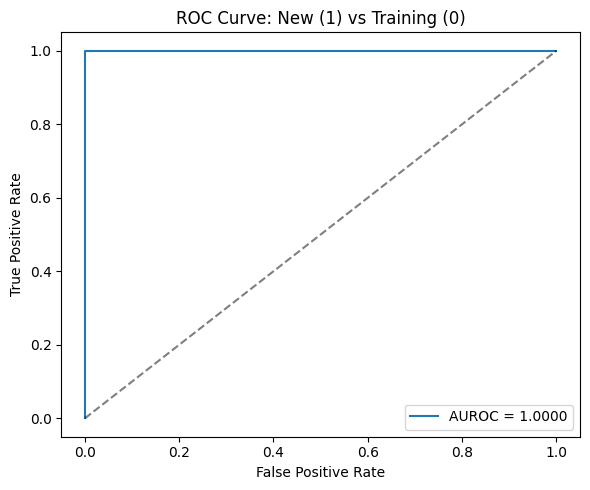

AUROC: 1.0
Confusion matrix [[TN, FP], [FN, TP]]: [[250, 0], [0, 250]]
Precision: 1.0
Recall: 1.0
F1: 1.0
ROC curve saved to: roc_curve.png


In [15]:
results, model = dataset_shift_report(
    train_df=train,
    new_df=new,
    model_name="logreg",           # or "random_forest"
    include_cols=['x1','x2','x3'],             # optional: list of columns to use
    exclude_cols='Category',             # optional: list of columns to drop from features
    test_size=0.25,
    threshold=0.5,
    scale_numeric=False            # set True if you want standardized numeric features
)

print("AUROC:", results["auroc"])
print("Confusion matrix [[TN, FP], [FN, TP]]:", results["confusion_matrix"])
print("Precision:", results["precision"])
print("Recall:", results["recall"])
print("F1:", results["f1"])
print("ROC curve saved to:", results["roc_curve_path"])

In [16]:
results

{'feature_cols': ['x1', 'x2', 'x3'],
 'test_size': 0.25,
 'threshold': 0.5,
 'auroc': 1.0,
 'confusion_matrix_labels': ['Predicted 0/Actual 0-1 order',
  'matrix -> [[TN, FP],[FN, TP]]'],
 'confusion_matrix': [[250, 0], [0, 250]],
 'precision': 1.0,
 'recall': 1.0,
 'f1': 1.0,
 'roc_curve_path': 'roc_curve.png',
 'model': "LogisticRegression(class_weight='balanced', max_iter=2000, random_state=42)"}

In [17]:
def data_report_by_category(
    project_name,
    train_df,
    new_df,
    model_name = "logreg",
    include_cols=None,
    exclude_cols=None,
    category_col = None,
    test_size = 0.25,
    threshold = 0.5,
    scale_numeric = False,
    random_state = 42
):
    category_freq_dist = train_df[category_col].value_counts()
    category_list = list(category_freq_dist.index)
    category_freq = list(category_freq_dist.values)
    features_name = ['auroc','precision','recall','f1']
    data_result = pd.DataFrame()
    for cat in category_list:
        train_df_cat = train_df[train_df[category_col] == cat]
        new_df_cat = new_df[new_df[category_col] == cat]
        values = []
        features_name_col = []
        if new_df_cat.shape[0] != 0:
            results, model = dataset_shift_report(
                                    train_df_cat,
                                    new_df_cat,
                                    model_name,           # or "random_forest"
                                    include_cols,             # optional: list of columns to use
                                    exclude_cols,             # optional: list of columns to drop from features
                                    test_size,
                                    threshold,
                                    scale_numeric,
                                    random_state,
                                    roc_png_path = "roc_curve_{model_name}_{cat}.jpg".format(model_name = model_name, cat = cat)
                                )
            for i in range(len(features_name)):
                features_name_col.append(features_name[i])
                values.append(results[features_name[i]])
            # print([results[feat] for feat in ['precision','recall']])
            
            data_cat_spec = pd.DataFrame({'features_name':features_name_col,'values':values})
            data_cat_spec['category_name'] = cat
            data_cat_spec['category_size'] = new_df_cat.shape[0]
        else:
            data_cat_spec = pd.DataFrame()
        data_result = pd.concat([data_result,data_cat_spec],axis = 0)
    if data_result.shape[0] != 0:
        data_result['project_name'] = project_name
        data_result['new_data_size'] = new_df.shape[0]
        data_result['eval_model_name'] = model_name
        data_result.reset_index(drop = True,inplace = True)
        data_result = data_result[['project_name','new_data_size','category_name','category_size','eval_model_name','features_name','values']]
    return data_result

In [18]:
import numpy as np
import pandas as pd

# Set seed for reproducibility
rng = np.random.default_rng(42)

# ------------ TRAIN DATASET ------------
train_df = pd.DataFrame()
for i in range(3):
    train = pd.DataFrame({
        "x1": rng.normal(35*0, 8+i, 1000).round(1),
        "x2": rng.lognormal(mean=10 + i, sigma=0.4, size=1000).round(2),
        "x3": rng.uniform(0 + i, 1 + i, 1000).round(3)
    })
    train['Category'] = i
    train_df = pd.concat([train_df,train],axis = 0)

# ------------ TEST DATASET ------------
new_df = pd.DataFrame()
for i in range(3):
    new = pd.DataFrame({
        "x1": rng.normal(35 + 0, 8+i, 1000).round(1),
        "x2": rng.lognormal(mean=10 - i, sigma=0.4, size=1000).round(2),
        "x3": rng.uniform(0 + i, 1 + i, 1000).round(3)
    })
    new['Category'] = i
    new_df = pd.concat([new_df,new],axis = 0)

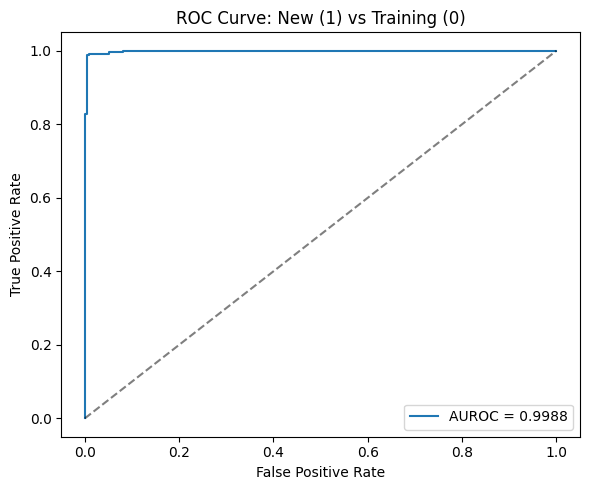

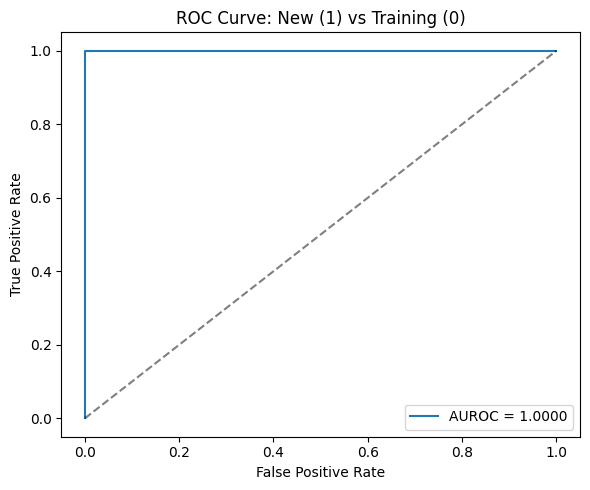

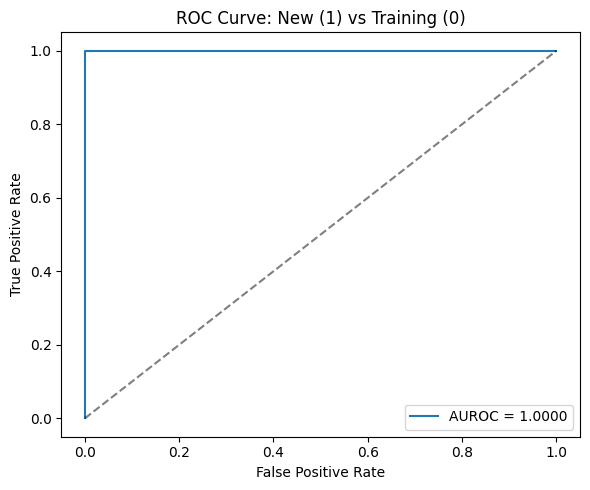

In [19]:
result_df = data_report_by_category(
    'Project_1',
    train_df,
    new_df,
    model_name = "logreg",
    include_cols=['x1','x2','x3'],
    exclude_cols=None,
    category_col = 'Category',
    test_size = 0.25,
    threshold = 0.5,
    scale_numeric = False,
    random_state = 42
)

In [20]:
result_df.to_csv('model_based_monitoring.csv',index = False)

In [21]:
result_df

,project_name,new_data_size,category_name,category_size,eval_model_name,features_name,values
0,Project_1,3000,0,1000,logreg,auroc,0.998800
1,Project_1,3000,0,1000,logreg,precision,0.976378
2,Project_1,3000,0,1000,logreg,recall,0.992000
3,Project_1,3000,0,1000,logreg,f1,0.984127
4,Project_1,3000,1,1000,logreg,auroc,1.000000
5,Project_1,3000,1,1000,logreg,precision,1.000000
6,Project_1,3000,1,1000,logreg,recall,1.000000
7,Project_1,3000,1,1000,logreg,f1,1.000000
8,Project_1,3000,2,1000,logreg,auroc,1.000000
9,Project_1,3000,2,1000,logreg,precision,1.000000
